In [4]:
import random
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from src.portfolio.download import MOEXCandlesFetcher
from src.dnn.prepare_dataloaders import FinTSDataloaders
from src.dnn.trainer import Trainer
from src.dnn.lstm_forecast import LSTMForecaster

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(123)

import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

%matplotlib inline

In [5]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TEST_START_DATE = "2024-10-17"

In [6]:
TICKERS = ["YNDX", "YDEX", "LKOH", "MGNT", "ROSN", "GAZP", "SBER", "CHMF", "NVTK"]
data_path = "./data/moex_may_report.csv"
fetcher = MOEXCandlesFetcher()
df = fetcher.run(data_path=data_path, tickers=TICKERS, from_date="2015-01-01")

df = df.ffill().bfill()
data = df[["ticker", "date", "close", "volume"]]

Загружены ранее скачанные данные ./data/moex_may_report.csv.


In [4]:
def transform_stock_data_for_dnn(df, ticker, forecast_horizon=7):
    new_df = df[df["ticker"] == ticker].copy()
    
    dnn_df = pd.DataFrame()
    dnn_df['ds'] = pd.to_datetime(new_df['date']).dt.tz_localize(None)
    dnn_df['ticker'] = ticker

    # Целевая переменная — доходность
    dnn_df['y_return'] = (new_df['close'].shift(-forecast_horizon) / new_df['close'] - 1) * 100
    dnn_df['y'] = new_df['close'].shift(-forecast_horizon)
    dnn_df['actual_close'] = new_df['close']
    
    for i in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 30, 60]:
        dnn_df[f'return_{i}d'] = new_df['close'].pct_change(periods=i) * 100

    for window in [5, 10, 20, 30, 60]:
        ma = new_df['close'].rolling(window=window).mean()
        dnn_df[f'ma{window}_return'] = (new_df['close'] / ma - 1) * 100

    for window in [5, 10, 20, 30, 60]:
        dnn_df[f'volatility_{window}d'] = new_df['close'].pct_change().rolling(window=window).std() * 100
        dnn_df[f'volume_volatility_{window}d'] = new_df['volume'].pct_change().rolling(window=window).std() * 100

    dnn_df['volume_ma5'] = new_df['volume'].rolling(window=5).mean()
    dnn_df['volume_ma20'] = new_df['volume'].rolling(window=20).mean()
    dnn_df['volume_ratio'] = dnn_df['volume_ma5'] / dnn_df['volume_ma20']
    
    # Удалим пропуски перед разметкой сплита
    dnn_df_clean = dnn_df.dropna().reset_index(drop=True)

    # Только теперь считаем индексы
    total_days = len(dnn_df_clean)
    train_end = int(total_days * 0.7)
    val_end = int(total_days * 0.9)

    dnn_df_clean['split'] = 'train'
    dnn_df_clean.loc[train_end:val_end - 1, 'split'] = 'validation'
    dnn_df_clean.loc[val_end:, 'split'] = 'test'
    
    return dnn_df_clean

In [5]:
full_df = pd.DataFrame()

for ticker in data["ticker"].unique():
    temp_df = transform_stock_data_for_dnn(df=data, ticker=ticker)
    full_df = pd.concat([full_df, temp_df])

In [6]:
full_df.split.value_counts()

split
train         13578
validation     3886
test           1943
Name: count, dtype: int64

In [7]:
# Clean data by removing NaN values
dnn_df_clean = full_df.dropna()
print(f"\nOriginal shape: {full_df.shape}")
print(f"Clean shape: {dnn_df_clean.shape}")


Original shape: (19407, 36)
Clean shape: (19407, 36)


In [8]:
from sklearn.preprocessing import StandardScaler

def prepare_dnn_data(df):

    # Select features
    feature_columns = []
    
    # Returns features
    for i in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 30, 60]:
        feature_columns.append(f'return_{i}d')
    
    # Moving average returns
    for window in [5, 10, 20, 30, 60]:
        feature_columns.append(f'ma{window}_return')
    
    # Volatility features
    for window in [5, 10, 20, 30, 60]:
        feature_columns.append(f'volatility_{window}d')
        feature_columns.append(f'volume_volatility_{window}d')
    
    # Volume features
    feature_columns.extend(['volume_ratio'])
    
    target_column = 'y_return'  # Changed from 'y' to 'y_return'
    
    # print(f"Number of features: {len(feature_columns)}")
    # print("\nFeatures used:")
    # for i, feat in enumerate(feature_columns, 1):
    #     print(f"{i}. {feat}")
    
    # Create scalers
    feature_scaler = StandardScaler()
    target_scaler = StandardScaler()
    
    # Split data
    train_data = df[df['split'] == 'train']
    val_data = df[df['split'] == 'validation']
    test_data = df[df['split'] == 'test']
    
    # Fit scalers on training data only
    feature_scaler.fit(train_data[feature_columns])
    target_scaler.fit(train_data[[target_column]])
    
    # Transform all sets
    X_train = feature_scaler.transform(train_data[feature_columns])
    y_train = target_scaler.transform(train_data[[target_column]])
    
    X_val = feature_scaler.transform(val_data[feature_columns])
    y_val = target_scaler.transform(val_data[[target_column]])
    
    X_test = feature_scaler.transform(test_data[feature_columns])
    y_test = target_scaler.transform(test_data[[target_column]])
    
    return (X_train, y_train, X_val, y_val, X_test, y_test, 
            feature_scaler, target_scaler, feature_columns)

In [9]:
(X_train, y_train, X_val, y_val, X_test, y_test,
 feature_scaler, target_scaler, feature_columns) = prepare_dnn_data(dnn_df_clean)

In [10]:
def generate_correlation_matrices(df: pd.DataFrame, window: int = 60) -> tuple:
    """
    Генерация последовательности корреляционных матриц по окну rolling window.
    """
    # pivot: [date x ticker] = return_1d
    returns_pivot = df.pivot(index="ds", columns="ticker", values="return_1d").sort_index()
    dates = returns_pivot.index

    corr_matrices = []
    for i in range(len(returns_pivot)):
        if i < window:
            corr_matrices.append(np.zeros((returns_pivot.shape[1], returns_pivot.shape[1])))
            continue

        window_data = returns_pivot.iloc[i-window:i]
        corr_matrix = window_data.corr().fillna(0).values
        corr_matrices.append(corr_matrix)

    # Сопоставим эти матрицы с датами в `df`
    corr_df = pd.DataFrame({
        "ds": dates,
        "corr_matrix": corr_matrices
    })

    # Теперь добавим к исходному df
    df = df.merge(corr_df, on="ds", how="left")

    # Отфильтруем по сплитам
    corr_train = df[df["split"] == "train"]["corr_matrix"].to_numpy()
    corr_val = df[df["split"] == "validation"]["corr_matrix"].to_numpy()
    corr_test = df[df["split"] == "test"]["corr_matrix"].to_numpy()

    # Преобразуем в массивы numpy
    corr_train = np.stack([m for m in corr_train if m is not np.nan])
    corr_val = np.stack([m for m in corr_val if m is not np.nan])
    corr_test = np.stack([m for m in corr_test if m is not np.nan])

    return corr_train, corr_val, corr_test

In [11]:
corr_train, corr_val, corr_test = generate_correlation_matrices(dnn_df_clean, window=60)

In [12]:
X_train.shape

(13578, 28)

In [13]:
y_train.shape

(13578, 1)

In [14]:
corr_train.shape

(13578, 8, 8)

In [15]:
import torch
from torch.utils.data import Dataset

class FinTSDataset(Dataset):
    def __init__(self, X, y, corr_matrices, window: int):
        """
        X: np.array, shape (N, num_features)
        y: np.array, shape (N, 1)
        corr_matrices: np.array, shape (N, num_tickers, num_tickers)
        """
        self.X = X
        self.y = y
        self.corr = corr_matrices
        self.window = window
        #self.dates = X.index

    def __len__(self):
        return len(self.X) - self.window

    def __getitem__(self, idx):
        X_window = torch.tensor(self.X[idx:idx + self.window], dtype=torch.float32)
        corr_window = torch.tensor(self.corr[idx:idx + self.window], dtype=torch.float32)
        y_target = torch.tensor(self.y[idx + self.window], dtype=torch.float32)

        return X_window, corr_window, y_target

In [16]:
from torch.utils.data import DataLoader

def create_dataloaders(X_train, y_train, corr_train,
                       X_val, y_val, corr_val,
                       X_test, y_test, corr_test,
                       window, batch_size):
    """
    Возвращает: train_loader, val_loader, test_loader
    """

    train_dataset = FinTSDataset(X_train, y_train, corr_train, window)
    val_dataset = FinTSDataset(X_val, y_val, corr_val, window)
    test_dataset = FinTSDataset(X_test, y_test, corr_test, window)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

In [17]:
window = 60
batch_size = 256

# Dataloaders
train_loader, val_loader, test_loader = create_dataloaders(
    X_train, y_train, corr_train,
    X_val, y_val, corr_val,
    X_test, y_test, corr_test,
    window=window,
    batch_size=batch_size
)

In [18]:
X_batch, corr_batch, y_batch = next(iter(train_loader))
feature_dim = X_batch.shape[2]
num_tickers = y_batch.shape[1]

In [19]:
import torch
import torch.nn as nn

class CNNEmbedding(nn.Module):
    def __init__(self, num_tickers, embed_dim=32):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(8),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.4),

            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.4),

            nn.AdaptiveAvgPool2d((2, 2)),
            nn.Flatten(),
            nn.Linear(16*2*2, embed_dim),
            nn.LeakyReLU(0.01)
        )

    def forward(self, x):
        b, t, n, _ = x.shape  # [batch, window, tickers, tickers]
        x = x.view(b * t, 1, n, n)
        emb = self.cnn(x)
        emb = emb.view(b, t, -1)
        return emb.mean(dim=1)  # [batch, embed_dim]


class LSTMWithCorrelation(nn.Module):
    def __init__(self, feature_dim, num_tickers, lstm_hidden=32, cnn_embed_dim=32):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=feature_dim,
            hidden_size=lstm_hidden,
            batch_first=True
        )
        self.cnn_embedding = CNNEmbedding(num_tickers=num_tickers, embed_dim=cnn_embed_dim)

        self.fc = nn.Sequential(
            nn.Linear(lstm_hidden + cnn_embed_dim, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.4),
            nn.Linear(32, num_tickers)
        )

    def forward(self, x_feat, x_corr):
        lstm_out, _ = self.lstm(x_feat)
        lstm_emb = lstm_out[:, -1, :]  # последний временной шаг

        cnn_emb = self.cnn_embedding(x_corr)
        combined = torch.cat([lstm_emb, cnn_emb], dim=1)

        return self.fc(combined)

In [20]:
model = LSTMWithCorrelation(
    feature_dim=X_batch.shape[2],
    num_tickers=y_batch.shape[1]
).to(DEVICE)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)

import copy

best_model_state = None
best_val_loss = float('inf')
patience = 10
patience_counter = 0

EPOCHS = 100

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0

    for X_batch, corr_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        corr_batch = corr_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()
        preds = model(X_batch, corr_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    # Validation
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for X_batch, corr_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            corr_batch = corr_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            preds = model(X_batch, corr_batch)
            loss = criterion(preds, y_batch)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)

    # Scheduler step
    scheduler.step(avg_val_loss)

    print(f"[{epoch+1}] Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Ранняя остановка на эпохе {epoch+1}")
            break

# Загрузка лучшей модели
model.load_state_dict(best_model_state)

[1] Train Loss: 1.074542 | Val Loss: 1.377748
[2] Train Loss: 1.005072 | Val Loss: 1.391221
[3] Train Loss: 0.978061 | Val Loss: 1.392429
[4] Train Loss: 0.968106 | Val Loss: 1.401035
[5] Train Loss: 0.943054 | Val Loss: 1.414836
[6] Train Loss: 0.934019 | Val Loss: 1.415105
[7] Train Loss: 0.923783 | Val Loss: 1.415738
[8] Train Loss: 0.913082 | Val Loss: 1.421252
[9] Train Loss: 0.900974 | Val Loss: 1.426076
[10] Train Loss: 0.902590 | Val Loss: 1.427892
[11] Train Loss: 0.900467 | Val Loss: 1.430560
Ранняя остановка на эпохе 11


<All keys matched successfully>

In [25]:
def make_predictions_torch(model, X_data, corr_data, target_scaler, dnn_subset_df, X_train, y_train, device="cuda"):
    """
    Make predictions using a PyTorch model and convert predicted returns to prices.
    """
    model.eval()

    X_tensor = torch.tensor(X_data, dtype=torch.float32).to(device)
    corr_tensor = torch.tensor(corr_data, dtype=torch.float32).to(device)

    with torch.no_grad():
        preds_scaled = model(X_tensor, corr_tensor).cpu().numpy()

    # Inverse transform to get returns (%)
    preds_returns = target_scaler.inverse_transform(preds_scaled)

    # Текущие цены закрытия (must be aligned!)
    current_prices = dnn_subset_df["actual_close"].values
    y_pred_prices = current_prices * (1 + preds_returns.flatten() / 100)

    # Calculate prediction std (на трейне, для доверительного интервала)
    with torch.no_grad():
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
        train_preds_scaled = model(X_train_tensor, torch.tensor(corr_train, dtype=torch.float32).to(device)).cpu().numpy()
    
    train_errors = train_preds_scaled - y_train
    error_std = np.std(train_errors)

    # CI
    conf_interval = error_std * 2
    returns_lower = preds_returns.flatten() - conf_interval
    returns_upper = preds_returns.flatten() + conf_interval

    prices_lower = current_prices * (1 + returns_lower / 100)
    prices_upper = current_prices * (1 + returns_upper / 100)

    return y_pred_prices, prices_lower, prices_upper

In [26]:
print("\nMaking predictions...")
train_pred, train_lower, train_upper = make_predictions_torch(model, X_train, corr_train, target_scaler,
                                                               dnn_df_clean[dnn_df_clean['split'] == 'train'],
                                                               X_train, y_train)
val_pred, val_lower, val_upper = make_predictions_torch(model, X_val, corr_val, target_scaler,
                                                         dnn_df_clean[dnn_df_clean['split'] == 'validation'],
                                                         X_train, y_train)
test_pred, test_lower, test_upper = make_predictions_torch(model, X_test, corr_test, target_scaler,
                                                            dnn_df_clean[dnn_df_clean['split'] == 'test'],
                                                            X_train, y_train)


Making predictions...


IndexError: too many indices for tensor of dimension 2

In [45]:
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

lstm_model = LSTMForecaster(
    feature_dim=feature_dim,
    num_tickers=num_tickers,
    lstm_hidden=256,
    lstm_layers=3,
    dropout=0.2,
    cnn_embed_dim=16
).to(DEVICE)

lstm_criterion = torch.nn.L1Loss()
lstm_optimizer = Adam(
    params=lstm_model.parameters(),
    lr=0.0001,
    weight_decay=0.001
)
lstm_scheduler = ReduceLROnPlateau(
    optimizer=lstm_optimizer,
    patience=5,
    factor=0.5
)

lstm_trainer = Trainer(
    model=lstm_model,
    criterion=lstm_criterion,
    optimizer=lstm_optimizer,
    scheduler=lstm_scheduler,
    device=DEVICE)

train_losses, val_losses = lstm_trainer.train(
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=100,
    patience=30,
    model_name="lstm_testtest"
)

Эпоха [10/100] | Train loss: 0.727320 | Val loss: 0.794181
Эпоха [20/100] | Train loss: 0.726284 | Val loss: 0.795066
Эпоха [30/100] | Train loss: 0.726120 | Val loss: 0.795387
Ранняя остановка на эпохе 35


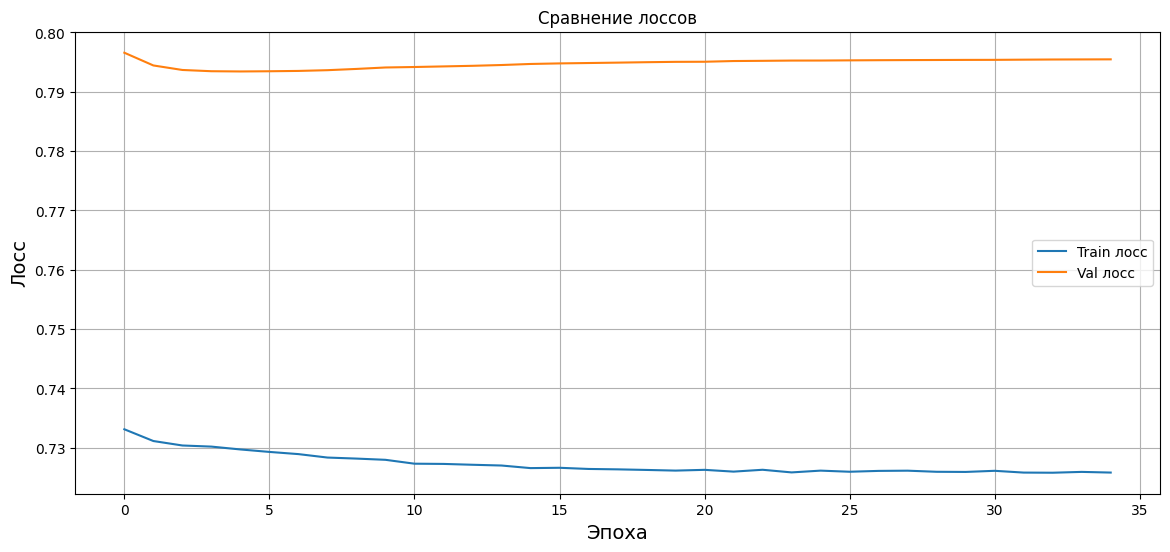

In [46]:
from src.ploting.utils import *

plot_losses(train_losses, val_losses)

In [47]:
lstm_loss = lstm_trainer.evaluate(dataloader=test_loader)

lstm_preds, lstm_targets, lstm_lb, lstm_ub = lstm_trainer.predict(
    dataloader=test_loader,
    target_scaler=target_scaler,
    train_loader=train_loader,
    ci_coef=1
)

Test loss: 1.022080


In [53]:
lstm_targets

array([[-3.2957501],
       [-5.059652 ],
       [-7.788873 ],
       ...,
       [-6.5222454],
       [-8.704106 ],
       [-6.7592807]], dtype=float32)

In [52]:
lstm_preds

array([[0.5718813 ],
       [0.5664647 ],
       [0.5554017 ],
       ...,
       [0.5054176 ],
       [0.4895353 ],
       [0.47724825]], dtype=float32)

In [ ]:
ticker = "SBER"

plot_dnn_predictions(
    df=data,
    dataloader=test_loader,
    ticker=ticker,
    preds=lstm_preds,
    targets=lstm_targets,
    lower_bounds=lstm_lb,
    upper_bounds=lstm_ub
)

AttributeError: 'FinTSDataset' object has no attribute 'dates'

In [7]:
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger
import torch

from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import SMAPE, QuantileLoss
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters

In [8]:
grouped = data.groupby("ticker")

for period in [5, 10, 20]:
    data[f"return_{period}d"] = grouped["close"].pct_change(periods=period)

for window in [5, 10, 20]:
    rolling_mean = grouped["close"].transform(lambda x: x.rolling(window).mean())
    data[f"ma_return_{window}d"] = data["close"] / rolling_mean - 1

for window in [5, 10, 20]:
    data[f"volatility_{window}d"] = grouped["close"].pct_change().rolling(window).std().reset_index(level=0, drop=True)

data["volume_ma5"] = grouped["volume"].rolling(window=5).mean().reset_index(level=0, drop=True)
data["volume_ma20"] = grouped["volume"].rolling(window=20).mean().reset_index(level=0, drop=True)
data["volume_ratio"] = data["volume_ma5"] / data["volume_ma20"]

data.fillna(method="ffill", inplace=True)
data.fillna(0, inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_1896\3342434302.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f"return_{period}d"] = grouped["close"].pct_change(periods=period)
C:\Users\User\AppData\Local\Temp\ipykernel_1896\3342434302.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f"return_{period}d"] = grouped["close"].pct_change(periods=period)


In [9]:
data["time_idx"] = data.groupby("ticker").cumcount()
data["return"] = data.groupby("ticker")["close"].pct_change().fillna(0)
data["day_of_week"] = data["date"].dt.weekday
data["month"] = data["date"].dt.month
data["day_of_month"] = data["date"].dt.day

In [10]:
max_prediction_length = 142
max_encoder_length = 150
training_cutoff = data["time_idx"].max() - max_prediction_length

In [11]:
time_varying_unknown_reals = [
    "close", "volume", "return",
    "return_5d", "return_10d", "return_20d",
    "ma_return_5d", "ma_return_10d", "ma_return_20d",
    "volatility_5d", "volatility_10d", "volatility_20d",
    "volume_ma5", "volume_ma20", "volume_ratio"
]

In [13]:
training = TimeSeriesDataSet(
    data[lambda x: x.time_idx < training_cutoff],
    time_idx="time_idx",
    target="return",
    group_ids=["ticker"],
    min_encoder_length=90, 
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    static_categoricals=["ticker"],
    time_varying_known_reals=["day_of_week", "month", "day_of_month"],
    time_varying_unknown_reals=time_varying_unknown_reals,
    target_normalizer=GroupNormalizer(groups=["ticker"], transformation=None),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True
)

validation = TimeSeriesDataSet.from_dataset(training, data, predict=True, stop_randomization=True)

batch_size = 512
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

In [10]:
# actuals = torch.cat([y for x, (y, weight) in iter(val_dataloader)]).to(DEVICE)
# baseline_predictions = Baseline().predict(val_dataloader)
# (actuals - baseline_predictions).abs().mean().item()

In [14]:
early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=50, verbose=True, mode="min")
lr_logger = LearningRateMonitor()  
logger = TensorBoardLogger("lightning_logs")  

trainer = pl.Trainer(
    max_epochs=100,
    accelerator="gpu", 
    devices=1,
    enable_model_summary=True,
    gradient_clip_val=0.1,
    callbacks=[lr_logger, early_stop_callback],
    logger=logger,
)


tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.001,
    hidden_size=160,
    attention_head_size=8,
    dropout=0.05,
    hidden_continuous_size=160,
    output_size=7,
    loss=QuantileLoss(),
    log_interval=10, 
    reduce_on_plateau_patience=4,
)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\User\Desktop\hsemaster\global_env\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\User\Desktop\hsemaster\global_env\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [16]:
total_params = sum(p.numel() for p in tft.parameters())
print(f"Всего параметров CNN+GRU+Attention: {total_params:,}")

Всего параметров CNN+GRU+Attention: 4,034,789


In [12]:
# trainer.fit(
#     tft,
#     train_dataloaders=train_dataloader,
#     val_dataloaders=val_dataloader,
# )

# best_model_path = trainer.checkpoint_callback.best_model_path
# best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

In [13]:
# actuals = torch.cat([y[0] for x, y in iter(val_dataloader)]).to(DEVICE)
# predictions = best_tft.predict(val_dataloader)

# #average p50 loss overall
# print((actuals - predictions).abs().mean().item())
# #average p50 loss per time series
# print((actuals - predictions).abs().mean(axis=1))

In [14]:
# raw_predictions = best_tft.predict(val_dataloader, mode="raw", return_x=True)

# for idx in range(8):
#     best_tft.plot_prediction(
#         raw_predictions.x, raw_predictions.output, idx=idx, add_loss_to_title=True
#     )

In [15]:
training_lite = TimeSeriesDataSet(
    data[lambda x: x.time_idx < training_cutoff],
    time_idx="time_idx",
    target="return",
    group_ids=["ticker"],
    min_encoder_length=60, 
    max_encoder_length=90,
    min_prediction_length=7,
    max_prediction_length=14,
    static_categoricals=["ticker"],
    time_varying_known_reals=["day_of_week", "month", "day_of_month"],
    time_varying_unknown_reals=time_varying_unknown_reals,
    target_normalizer=GroupNormalizer(groups=["ticker"], transformation=None),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True
)

validation_lite = TimeSeriesDataSet.from_dataset(training_lite, data, predict=True, stop_randomization=True)

train_dataloader_lite = training_lite.to_dataloader(train=True, batch_size=256, num_workers=0)
val_dataloader_lite = validation_lite.to_dataloader(train=False, batch_size=256, num_workers=0)

In [16]:
early_stop_callback_l = EarlyStopping(monitor="val_loss", patience=30, verbose=True, mode="min")
lr_logger_l = LearningRateMonitor()  
logger_l = TensorBoardLogger("lightning_logs")  

trainer_lite = pl.Trainer(
    max_epochs=100,
    accelerator="gpu", 
    devices=1,
    enable_model_summary=True,
    gradient_clip_val=0.1,
    callbacks=[lr_logger_l, early_stop_callback_l],
    logger=logger_l,
    log_every_n_steps=10
)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [17]:
tft_lite = TemporalFusionTransformer.from_dataset(
    training_lite,
    learning_rate=0.001,
    hidden_size=256,
    attention_head_size=8,
    dropout=0.1,
    hidden_continuous_size=256,
    output_size=7,
    loss=QuantileLoss(),
    log_interval=10, 
    reduce_on_plateau_patience=4,
)

c:\Users\User\Desktop\hsemaster\global_env\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\User\Desktop\hsemaster\global_env\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [18]:
trainer_lite.fit(
    tft_lite,
    train_dataloaders=train_dataloader_lite,
    val_dataloaders=val_dataloader_lite,
)

lite_model_path = trainer_lite.checkpoint_callback.best_model_path
lite_tft_model = TemporalFusionTransformer.load_from_checkpoint(lite_model_path)

You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 40     | train
3  | prescalers                         | ModuleDict                      | 11.3 K | train
4  | static_variable_selection          |

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\User\Desktop\hsemaster\global_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\User\Desktop\hsemaster\global_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_loss did not improve in the last 30 records. Best score: 0.010. Signaling Trainer to stop.
c:\Users\User\Desktop\hsemaster\global_env\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\User\Desktop\hsemaster\global_env\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [19]:
actuals_l = torch.cat([y[0] for x, y in iter(val_dataloader_lite)]).to(DEVICE)
predictions_l = lite_tft_model.predict(val_dataloader_lite)

#average p50 loss overall
print((actuals_l - predictions_l).abs().mean().item())
#average p50 loss per time series
print((actuals_l - predictions_l).abs().mean(axis=1))

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


0.023117592558264732
tensor([0.0277, 0.0270, 0.0150, 0.0222, 0.0329, 0.0253, 0.0126, 0.0222],
       device='cuda:0')


c:\Users\User\Desktop\hsemaster\global_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


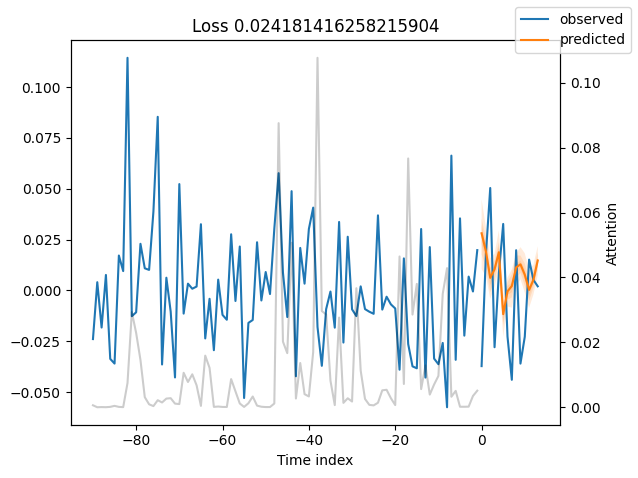

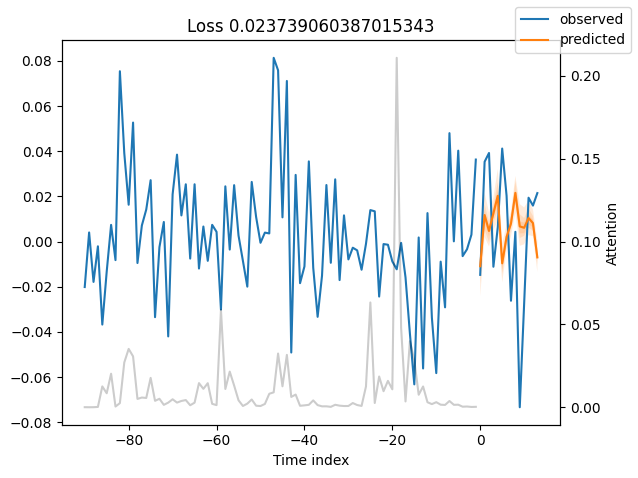

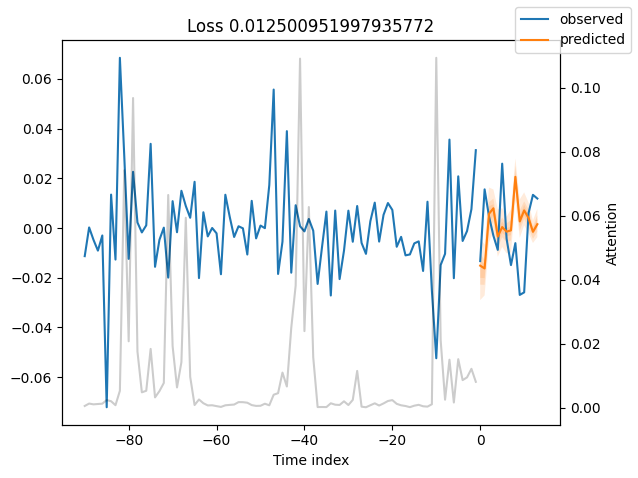

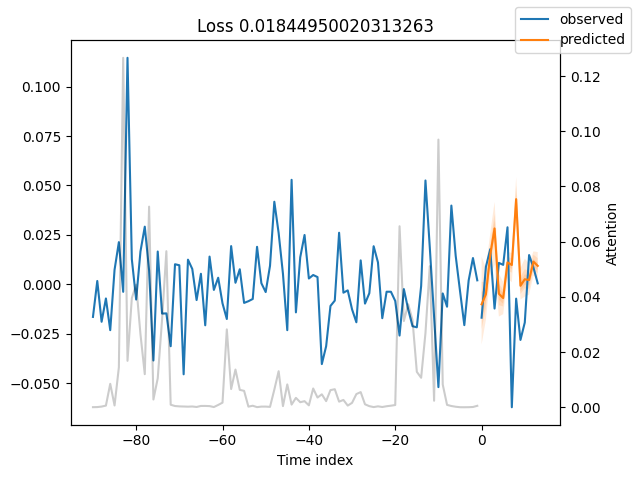

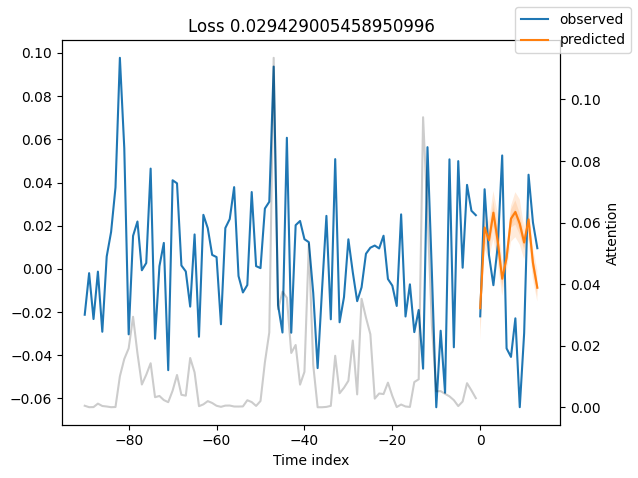

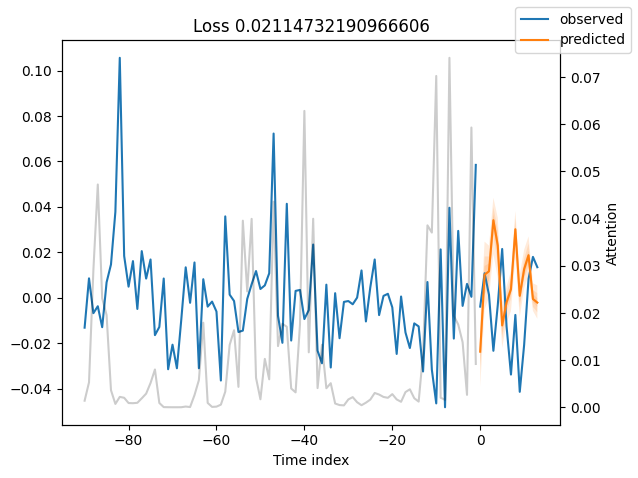

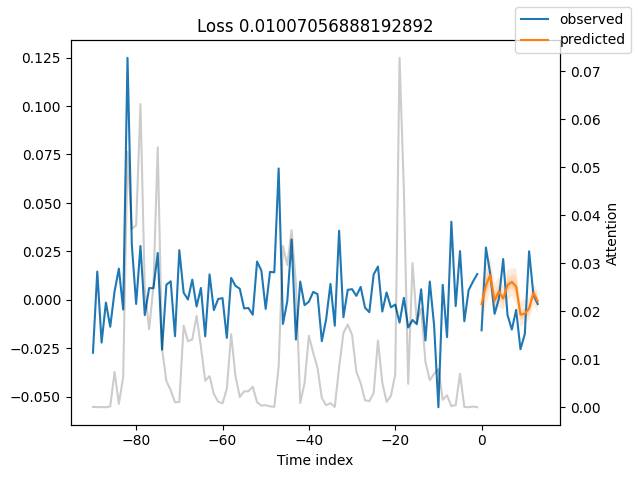

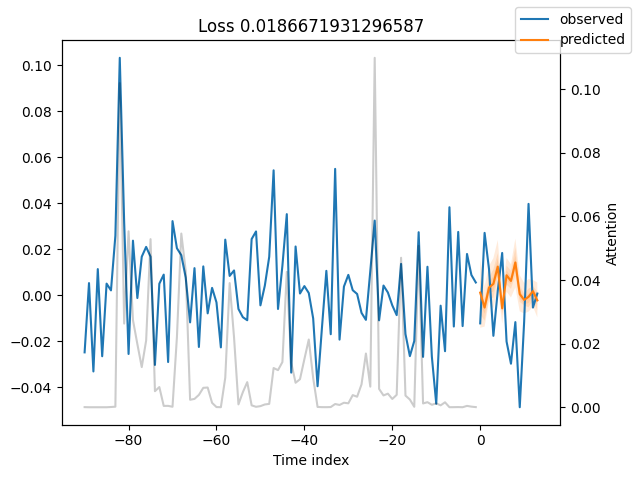

In [20]:
raw_predictions_l = lite_tft_model.predict(val_dataloader_lite, mode="raw", return_x=True)

for idx in range(8):
    lite_tft_model.plot_prediction(
        raw_predictions_l.x, raw_predictions_l.output, idx=idx, add_loss_to_title=True
    )

C:\Users\User\AppData\Local\Temp\ipykernel_36740\918227408.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


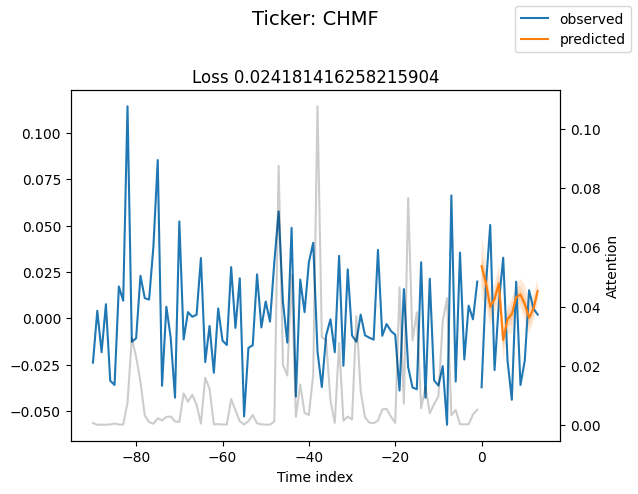

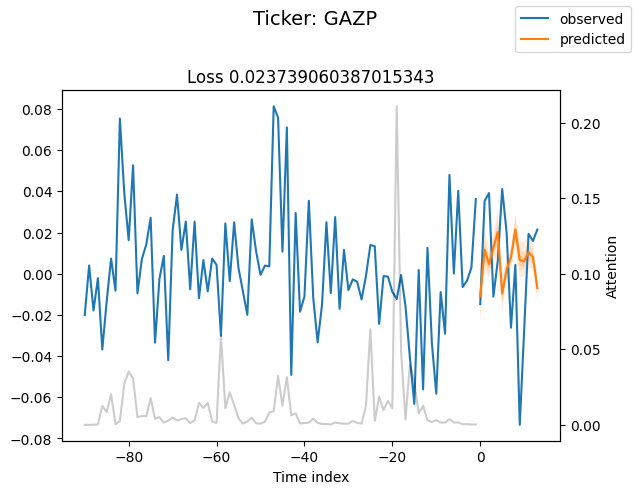

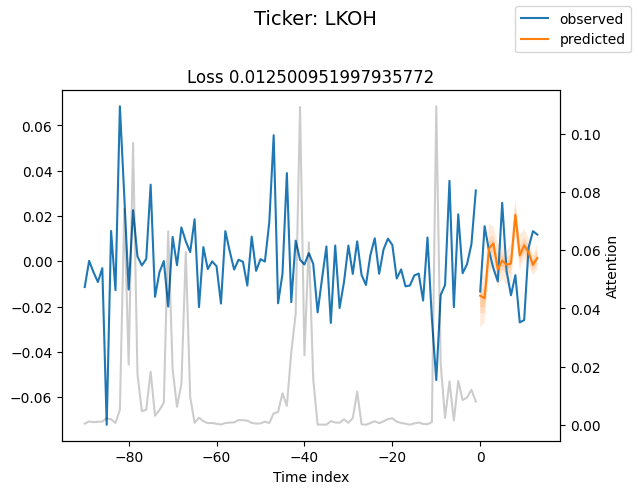

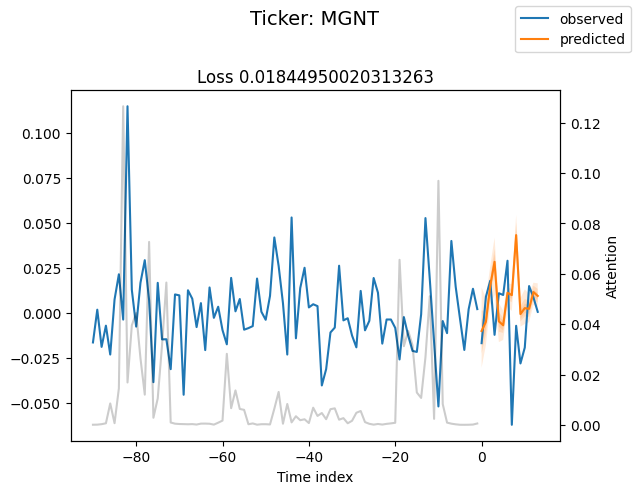

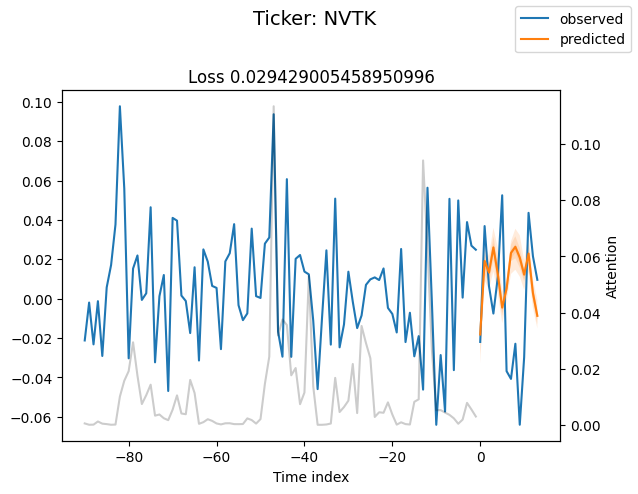

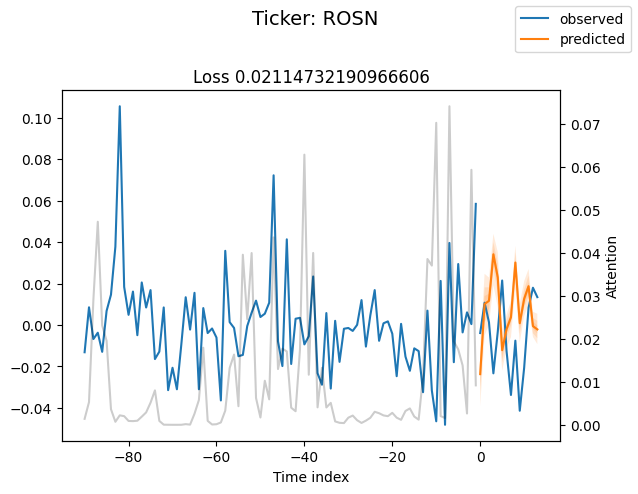

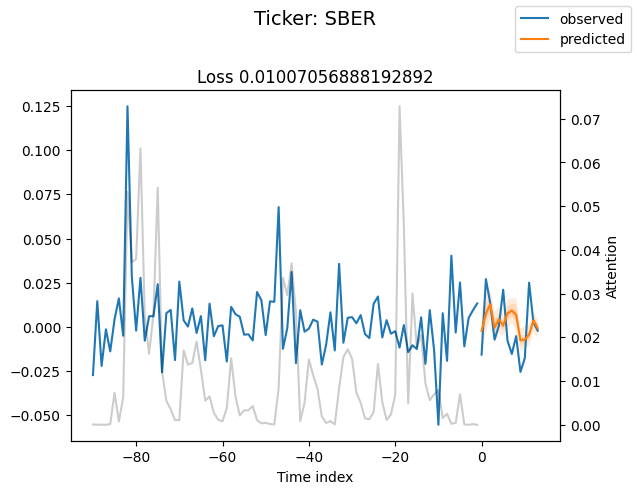

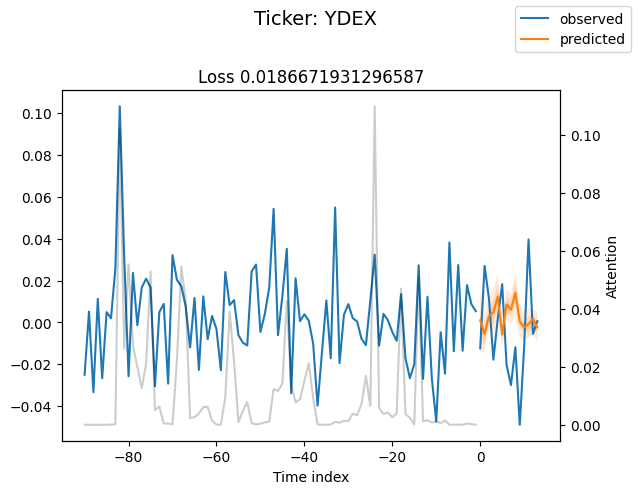

In [21]:
tickers = val_dataloader_lite.dataset.categorical_encoders["ticker"].inverse_transform(
    raw_predictions_l.x["groups"].cpu().numpy().flatten()
)

for idx in range(8):
    ticker = tickers[idx]
    fig = lite_tft_model.plot_prediction(
        raw_predictions_l.x, raw_predictions_l.output, idx=idx, add_loss_to_title=True
    )
    fig.suptitle(f"Ticker: {ticker}", fontsize=14, y=1.02)
    fig.tight_layout()
    fig.show()

In [22]:
study = optimize_hyperparameters(
    train_dataloader_lite,
    val_dataloader_lite,
    model_path="optuna_tft",
    n_trials=150,
    max_epochs=50,
    gradient_clip_val_range=(0.01, 1.0),
    hidden_size_range=(64, 512),
    hidden_continuous_size_range=(32, 256),
    attention_head_size_range=(1, 8),
    dropout_range=(0.05, 0.3),
    learning_rate_range=(0.0001, 0.01),
    trainer_kwargs=dict(accelerator="gpu", devices=1, gradient_clip_val=0.1),
    reduce_on_plateau_patience=4,
    use_learning_rate_finder=False,
    verbose=2
)
print("Лучшие параметры:", study.best_trial.params)

[I 2025-05-17 15:06:27,066] A new study created in memory with name: no-name-98de3589-fbdb-431a-9deb-362bba3f3097
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\User\Desktop\hsemaster\global_env\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\User\Desktop\hsemaster\global_env\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                               | Type                            | Params | Mode 
------------------------------------------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\User\Desktop\hsemaster\global_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\User\Desktop\hsemaster\global_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

[I 2025-05-17 20:21:41,291] Trial 149 pruned. Trial was pruned at epoch 1.


Лучшие параметры: {'gradient_clip_val': 0.09857664984814268, 'hidden_size': 91, 'dropout': 0.1361402082817987, 'hidden_continuous_size': 38, 'attention_head_size': 5, 'learning_rate': 0.0011273627572590172}


In [26]:
best_params_final = study.best_trial.params
best_params_final

{'gradient_clip_val': 0.09857664984814268,
 'hidden_size': 91,
 'dropout': 0.1361402082817987,
 'hidden_continuous_size': 38,
 'attention_head_size': 5,
 'learning_rate': 0.0011273627572590172}

In [27]:
optimized_tft = TemporalFusionTransformer.from_dataset(
    training_lite,
    learning_rate=best_params_final["learning_rate"],
    hidden_size=best_params_final["hidden_size"],
    attention_head_size=best_params_final["attention_head_size"],
    hidden_continuous_size=best_params_final["hidden_continuous_size"],
    dropout=best_params_final["dropout"],
    loss=QuantileLoss(),
    output_size=7,
    log_interval=10,
    reduce_on_plateau_patience=4,
)

c:\Users\User\Desktop\hsemaster\global_env\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\User\Desktop\hsemaster\global_env\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [29]:
early_stop_callback_opt = EarlyStopping(monitor="val_loss", patience=20)
lr_logger_opt = LearningRateMonitor()  
logger_opt = TensorBoardLogger("lightning_logs")  

trainer_opt = pl.Trainer(
    max_epochs=100,
    accelerator="gpu",
    devices=1,
    gradient_clip_val=best_params_final["gradient_clip_val"],
    callbacks=[early_stop_callback_opt, lr_logger_opt],
    logger=logger_opt,
    log_every_n_steps=10
)

trainer_opt.fit(
    optimized_tft,
    train_dataloaders=train_dataloader_lite,
    val_dataloaders=val_dataloader_lite
)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 40     | train
3  | prescalers                         | ModuleDict                      | 1.7 K  | train
4  | static_variable_selection          | VariableSelectionNetwork        | 32.6 K | train
5  | encoder_variable_selection         

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\User\Desktop\hsemaster\global_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\User\Desktop\hsemaster\global_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [31]:
predictions_opt = optimized_tft.predict(val_dataloader_lite)
actuals_opt = torch.cat([y[0] for x, y in iter(val_dataloader_lite)]).to(DEVICE)

raw_predictions_opt = optimized_tft.predict(val_dataloader_lite, mode="raw", return_x=True)

mae = (actuals_opt - predictions_opt).abs().mean().item()
print(f"MAE после Optuna: {mae:.4f}")

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE после Optuna: 0.0191


C:\Users\User\AppData\Local\Temp\ipykernel_36740\2762580250.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


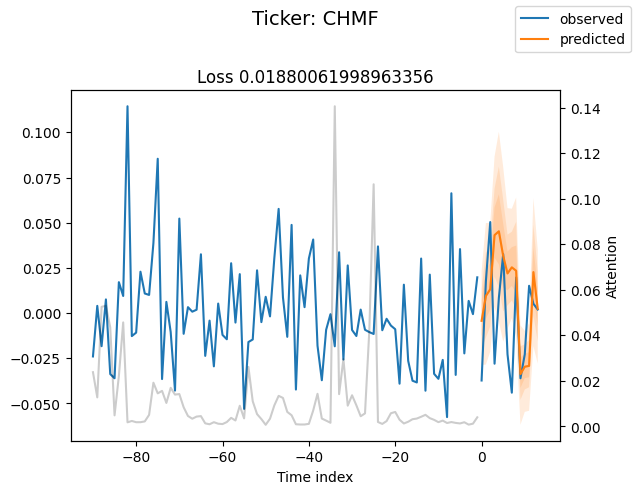

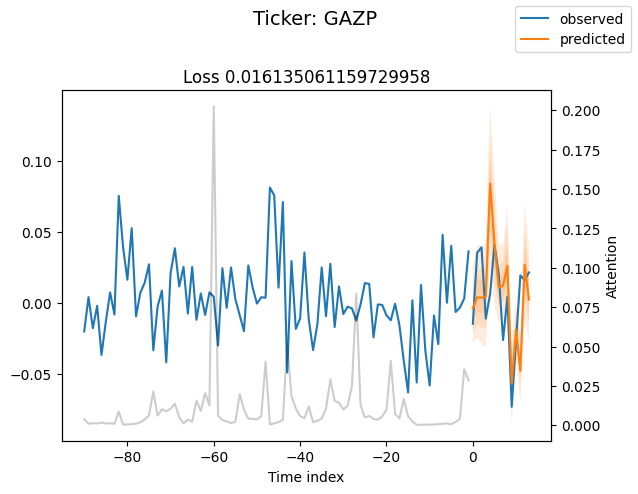

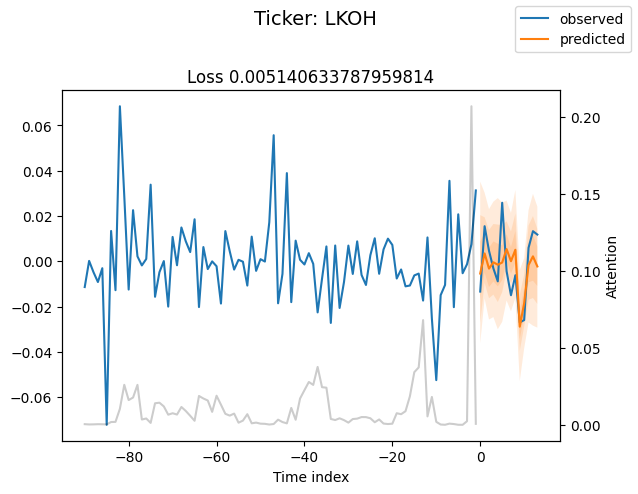

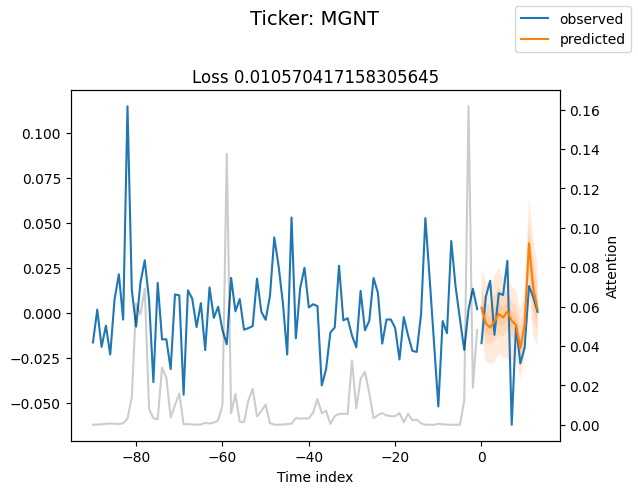

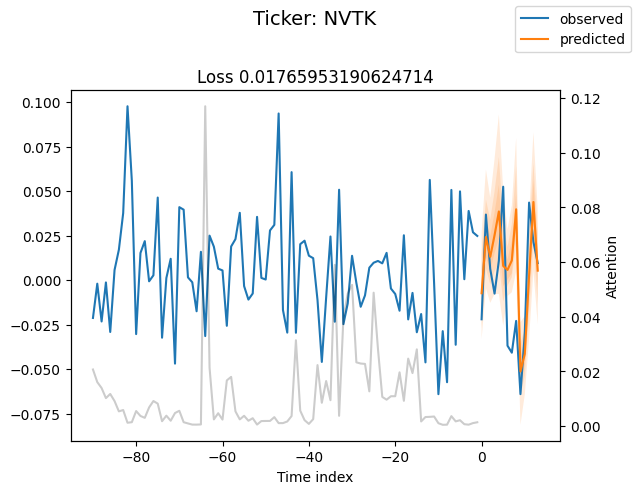

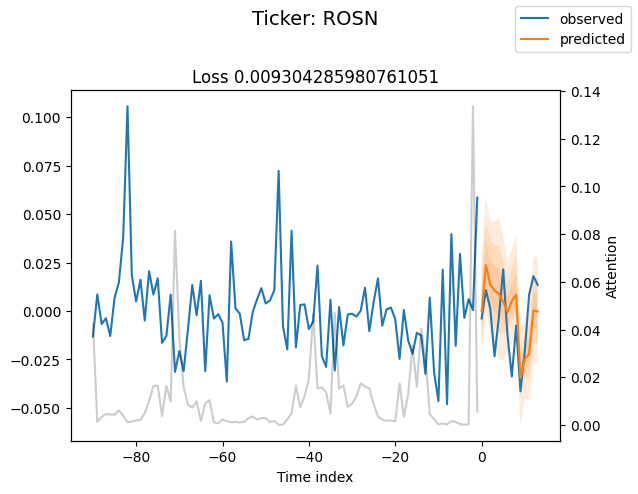

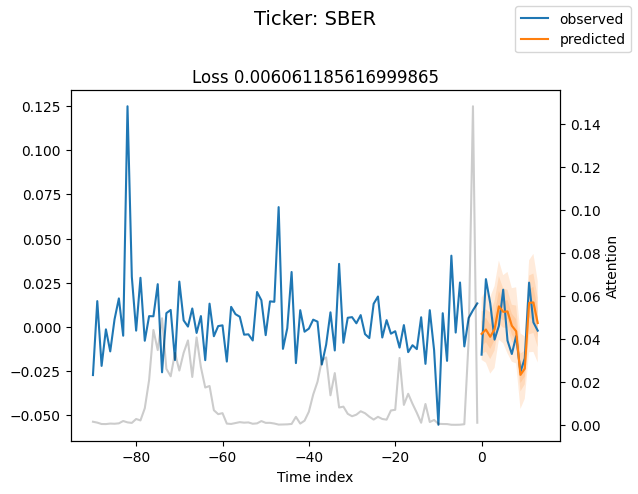

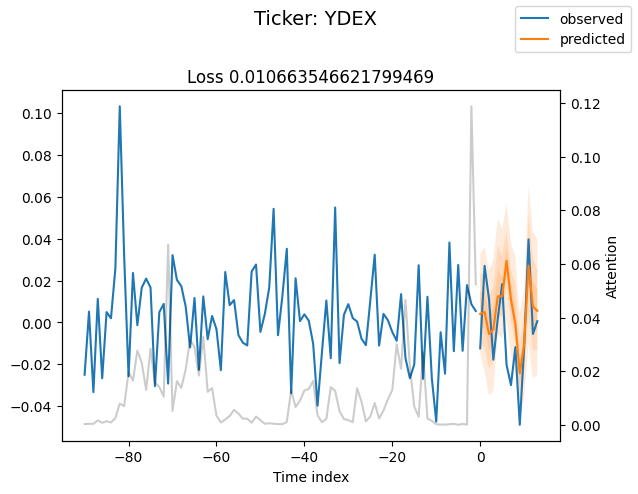

In [32]:
tickers = val_dataloader_lite.dataset.categorical_encoders["ticker"].inverse_transform(
    raw_predictions_opt.x["groups"].cpu().numpy().flatten()
)

for idx in range(8):
    ticker = tickers[idx]
    fig = optimized_tft.plot_prediction(
        raw_predictions_opt.x, raw_predictions_opt.output, idx=idx, add_loss_to_title=True
    )
    fig.suptitle(f"Ticker: {ticker}", fontsize=14, y=1.02)
    fig.tight_layout()
    fig.show()

In [23]:
# если цена закрытия
# predicted_returns = predictions_l[:, 1:] / predictions_l[:, :-1] - 1
# actual_returns = actuals_l[:, 1:] / actuals_l[:, :-1] - 1

# mae_returns = (actual_returns - predicted_returns).abs().mean().item()
# print(f"MAE на доходностях (полученных из цен): {mae_returns:.4f}")